# 🎬 Netflix Film ve Dizi Analizi


## Grup Üyeleri

*   Pelin KAYA
*   Özge EMRE
*   Cennet PAYAM

## Veri Seti
Netflix Movies and TV Shows  

## Kaggle Linki
https://www.kaggle.com/datasets/shivamb/netflix-shows



## 🔍 Veri Seti Seçme Nedeni

Dijital yayın platformlarının günümüz eğlence sektöründeki baskın rolünü ve Netflix'in bu alandaki pazar liderliğini analiz etmek amacıyla bu veri setini seçtik.

Bu veri seti, Netflix platformunda 2021 yılına kadar yayınlanmış olan tüm film ve dizi içeriklerini temsil etmektedir. Veri seti; içeriklerin türü (film/dizi), yönetmenleri, oyuncu kadroları, yayınlandıkları ülkeler, platforma eklenme tarihleri, yapım yılları ve yaş kategorileri (rating) gibi zengin meta veriler içermektedir.

Bu çalışma ile şu sorulara cevap aranmıştır:

-Netflix kütüphanesinde film mi yoksa dizi mi daha ağırlıklı?

-İçerik üretiminde hangi ülkeler lider konumda?

-Yıllara göre içerik sayısındaki artış hızı nasıl bir seyir izliyor?

-İçeriklerin yaş gruplarına göre dağılımı nasıl?

-Kütüphaneyi sayıca domine eden en üretken yönetmenler kimler?

-Netflix, içerik yüklemek için yılın belirli aylarını mı tercih ediyor?

-Film süreleri ile içerik türleri arasında anlamlı bir ilişki var mı?"


In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
import os
import warnings
warnings.filterwarnings("ignore")


In [205]:
df = pd.read_csv("netflix_titles.csv")

In [206]:
df.head() #ilk 5 satırı gösterir

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [207]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [208]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [209]:
df.shape #veri seti boyutu
df.info() #genel bilgiler
df.describe() #istatistiksel özet

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## 🧹 Veri Temizleme

Veri seti üzerinde eksik veriler, yinelenen kayıtlar ve veri tipleri kontrol edilmiştir.

- Veri setindeki hangi sütunlarda eksik (NaN) veri olduğunu belirlemek için isnull().sum() fonksiyonunu kullandık. Bu işlem, hangi alanlarda veri tamamlama veya silme yapmamız gerektiğini anlamamızı sağladı.


In [210]:
print(df.isnull().sum()) #eksik değerlerin toplamı
df.drop_duplicates(inplace=True) # Mükerrer kayıt kontrolü ve silme

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [211]:
df.isnull().sum()/(len(df))*100 #boş değerlerin yüzdesi

,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.908028
cast,9.367549
country,9.435676
date_added,0.113546
release_year,0.000000
rating,0.045418
duration,0.034064


## ⚙️ Feature Engineering

Veri analizi için yeni değişkenler oluşturulmuştur.

- date_added: Metin formatından datetime formatına dönüştürülmüştür.
- year_added: İçeriklerin eklendiği yıl analiz edilmiştir.
- duration_int: Süre bilgisi sayısal hale getirilmiştir.

In [212]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year #Platforma eklenme yılı

# Sadece filmlerin süresini (dakika) çekmek için:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_minutes'] = df_movies['duration'].str.replace(' min', '').astype(float)

# Sadece dizilerin sezon sayısını çekmek için:
df_shows = df[df['type'] == 'TV Show'].copy()
df_shows['seasons'] = df_shows['duration'].str.extract(r'(\d+)').astype(float)

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

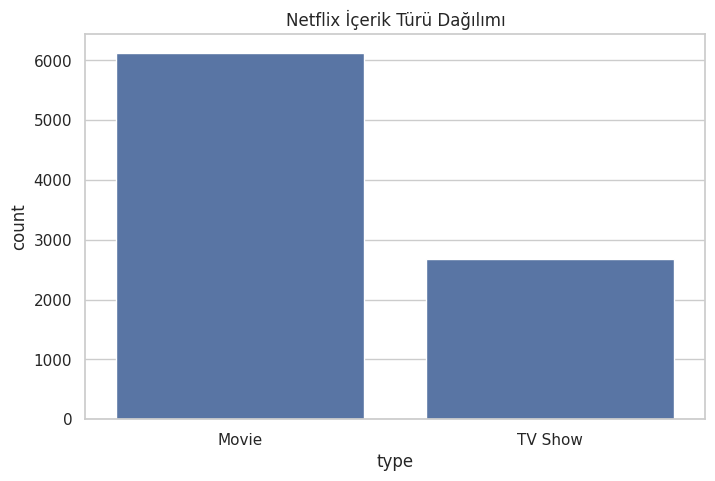

In [214]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df)
plt.title("Netflix İçerik Türü Dağılımı")
plt.show()


Netflix kütüphanesindeki içeriklerin oransal olarak "Film" mi yoksa "TV Show" mu olduğunu göstermektedir.

Kütüphanenin yaklaşık %70'ini filmlerin oluşturduğu görülmektedir.

Netflix son yıllarda dizi platformu olarak popülerlik kazansa da, sayısal olarak film arşivinin dizilerden kat kat daha büyük olması şaşırtıcı bir veridir.

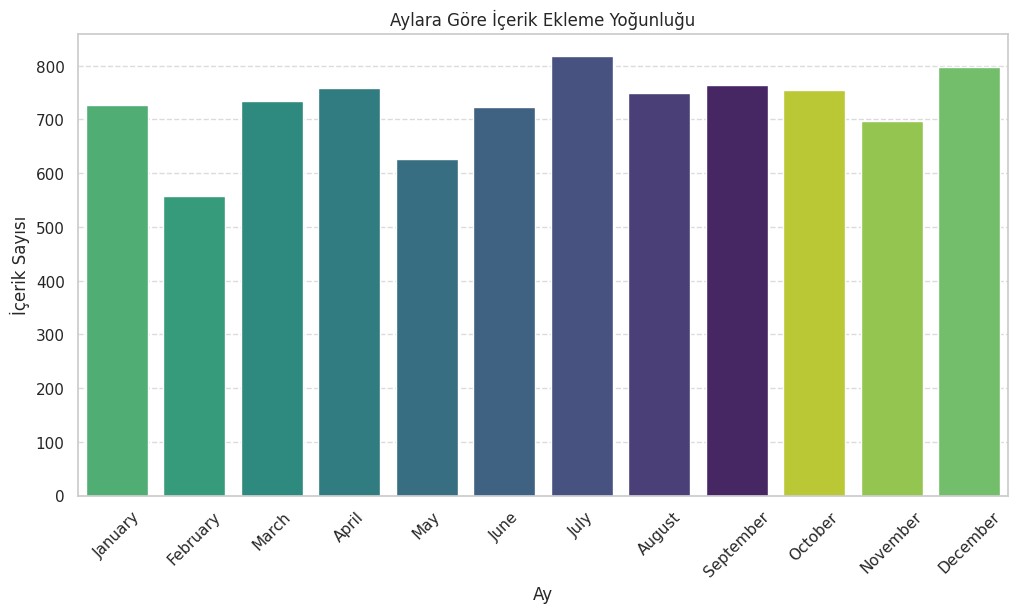

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veri setinden ay ismini çekme
df['month_added'] = df['date_added'].dt.month_name()

# Ayların sırasını belirleme
monthly_order = ['January', 'February', 'March', 'April', 'May', 'June',
                 'July', 'August', 'September', 'October', 'November', 'December']

# Görselleştirme
plt.figure(figsize=(12, 6))

# Güncel Seaborn formatı (Hata ve uyarı vermez)
sns.countplot(
    data=df,
    x='month_added',
    order=monthly_order,
    hue='month_added',
    palette='viridis',
    legend=False
)

plt.title('Aylara Göre İçerik Ekleme Yoğunluğu')
plt.xlabel('Ay')
plt.ylabel('İçerik Sayısı')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Daha okunabilir olması için hafif çizgiler
plt.show()

 Netflix'in yılın hangi aylarında daha fazla içerik yüklediğini (sezonsal yoğunluğunu) gösterir.

 İçerik ekleme işlemlerinin genellikle yılın son çeyreğinde (Ekim, Kasım, Aralık) ve yıl başlarında (Ocak) zirve yaptığı görülmektedir.

Yaz aylarında (Haziran-Temmuz) içerik yükleme sayısının diğer aylara göre daha düşük kalması, insanların yazın ekran başında daha az vakit geçireceği varsayımıyla yapılan stratejik bir tercih olabilir.

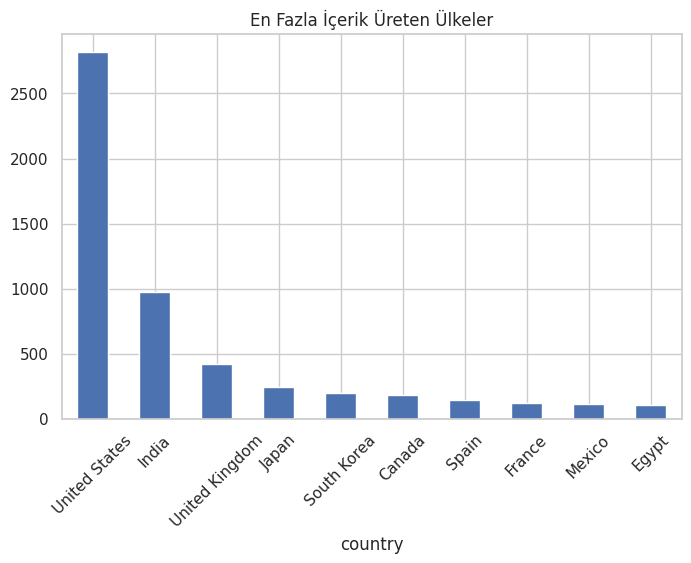

In [216]:
plt.figure(figsize=(8,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("En Fazla İçerik Üreten Ülkeler")
plt.xticks(rotation=45)
plt.show()

Grafik içeriklerin hangi ülkelerde üretildiğini ve global kütüphanedeki pazar paylarını göstermektedir.

Amerika Birleşik Devletleri açık ara liderdir; onu Hindistan ve Birleşik Krallık takip etmektedir.

Hindistan'ın özellikle film kategorisinde İngiltere gibi köklü bir sinema kültürünü geride bırakarak ikinci sıraya yerleşmesi, Netflix'in Bollywood pazarına verdiği önemi kanıtlamaktadır.

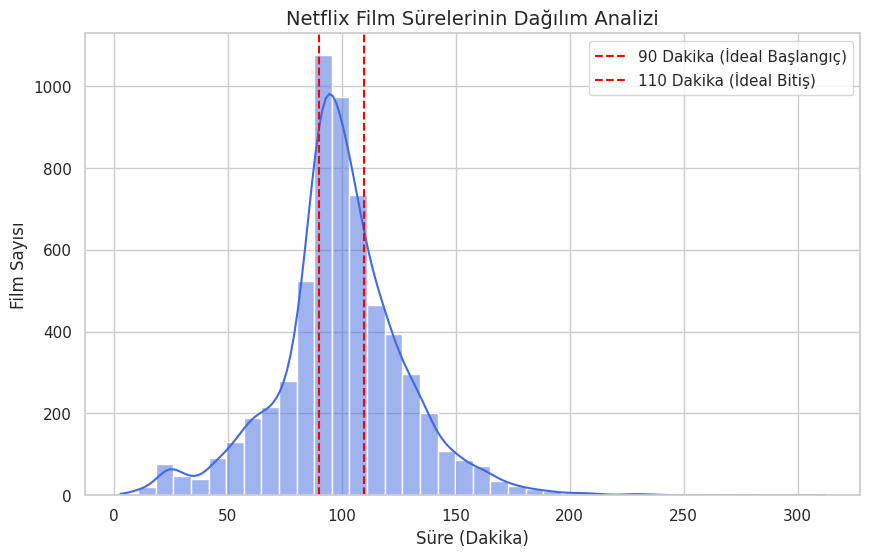

In [217]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# filmleri al ve süreleri sayıya çevir
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(float)

# Grafik oluşturma (Histogram ve Yoğunluk Çizgisi)
plt.figure(figsize=(10, 6))
sns.histplot(movies_df['duration_min'], bins=40, kde=True, color='royalblue')

# Grafik üzerine açıklayıcı çizgiler
plt.axvline(90, color='red', linestyle='--', label='90 Dakika (İdeal Başlangıç)')
plt.axvline(110, color='red', linestyle='--', label='110 Dakika (İdeal Bitiş)')

# 4. Etiketler ve Başlık
plt.title('Netflix Film Sürelerinin Dağılım Analizi', fontsize=14)
plt.xlabel('Süre (Dakika)')
plt.ylabel('Film Sayısı')
plt.legend()

plt.show()

Platformdaki filmlerin kaç dakika sürdüğünü ve hangi süre aralıklarında yoğunlaştığını göstermektedir.

Filmlerin büyük çoğunluğu 90-110 dakika arasındadır; bu da ideal izleyici odaklanma süresidir.

40 dakikanın altındaki çok kısa filmlerin ve 200 dakikayı aşan çok uzun filmlerin nadir olması, platformun standart yayıncılık sürelerini sıkı takip ettiğini gösterir.

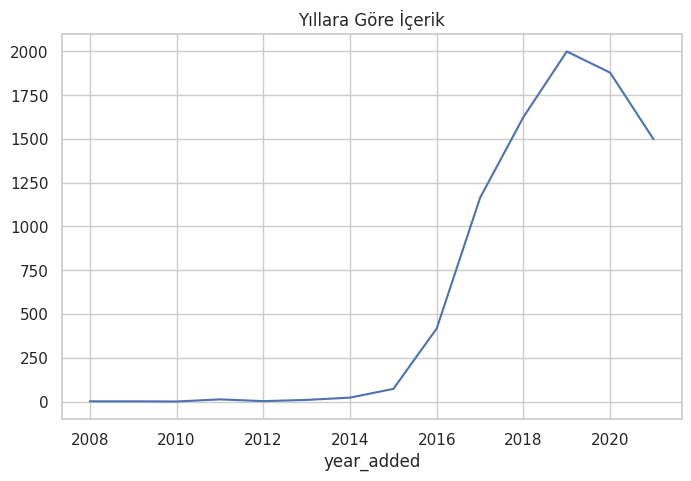

In [218]:
plt.figure(figsize=(8,5))
df['year_added'].value_counts().sort_index().plot()
plt.title("Yıllara Göre İçerik")
plt.show()

2008'den günümüze kadar Netflix'e her yıl eklenen yeni içeriklerin toplam sayısını göstermektedir.

2015 yılından itibaren içerik girişinde dikey bir ivme yaşandığı görülmektedir.

2020-2021 yıllarında pandemiden dolayı çekimlerin durmasına rağmen içerik ekleme sayısının yüksek seyretmesi, Netflix'in kütüphanesini önceden depoladığı içeriklerle beslediğini göstermektedir.

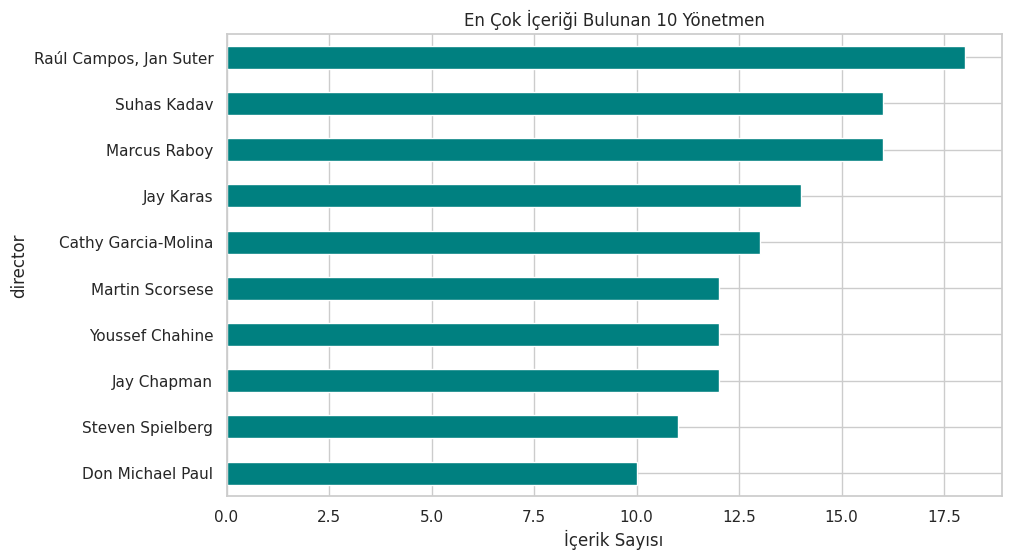

In [219]:
# En çok içeriği olan 10 yönetmen
top_directors = df['director'].value_counts()[1:11] # İlk sırada genelde boş veriler olduğu için 1'den başlattık

plt.figure(figsize=(10,6))
top_directors.plot(kind='barh', color='teal')
plt.gca().invert_yaxis() # En çok olanı üste alır
plt.title('En Çok İçeriği Bulunan 10 Yönetmen')
plt.xlabel('İçerik Sayısı')
plt.show()

Netflix kütüphanesinde en fazla yapımı bulunan (hem film hem dizi toplamı) ilk 10 yönetmeni listeler.

Jan Suter ve Raúl Campos gibi isimler de çok sayıda stand-up ve özel içerikle listede üst sıralardadır.

Dünyaca ünlü Hollywood yönetmenlerinden ziyade, platformun çocuk içerikleri veya yerel pazarlar (Bollywood gibi) için seri üretim yapan yönetmenlerin sayıca daha üstün olması şaşırtıcı bir sonuçtur.

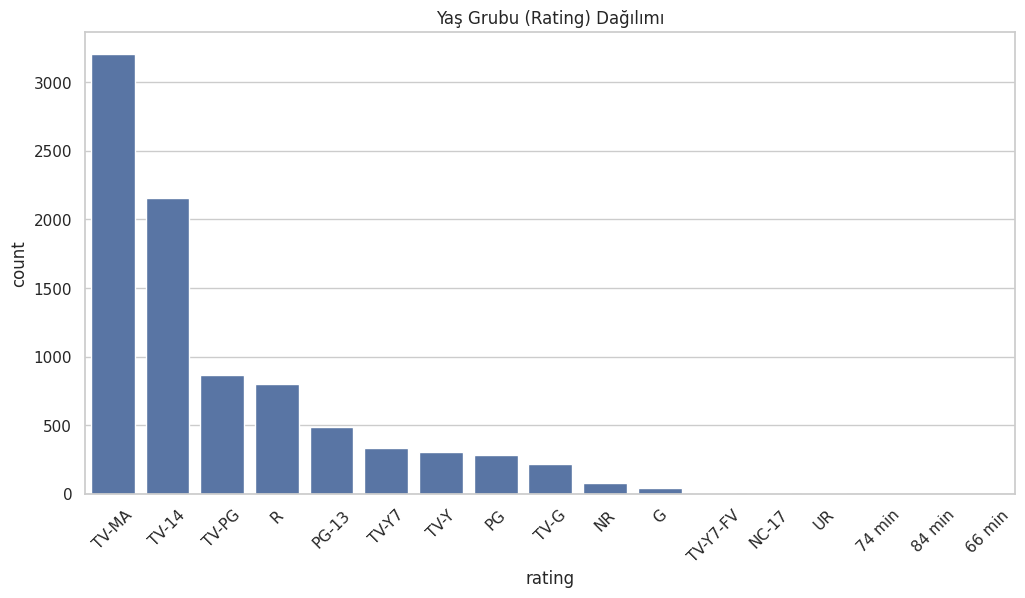

In [220]:
plt.figure(figsize=(12,6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Yaş Grubu (Rating) Dağılımı")
plt.show()

Bu grafik içeriklerin yaş sınıflandırmasına göre dağılımını göstermektedir.
Belirli yaş gruplarına yönelik içeriklerin daha fazla olduğu görülmektedir.

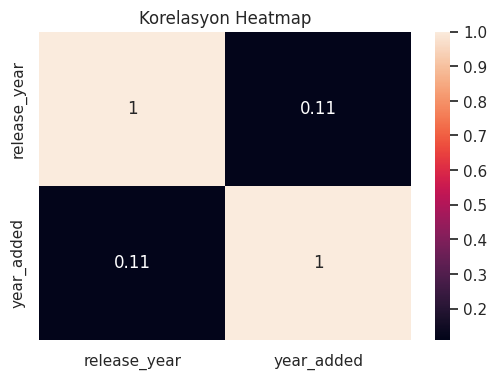

In [221]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Korelasyon Heatmap")
plt.show()

Bu grafik sayısal değişkenler arasındaki ilişkiyi göstermektedir.
Değişkenler arasında güçlü bir korelasyon bulunmadığı görülmektedir.

release_year ve year_added (0.11): Yapım yılı ile Netflix'e eklenme yılı arasında neredeyse hiç bağ yok. Yani eski filmler de yeni filmler de benzer yoğunlukta platforma ekleniyor diyebiliriz.

release_year ve duration_int (-0.25): Buradaki negatif değer, yıllar geçtikçe (yıl arttıkça) sürelerin çok hafif de olsa kısalma eğiliminde olduğunu gösterebilir; ancak -0.25 çok zayıf bir değer olduğu için "yıllar geçtikçe süreler kısalıyor" demek için yeterli bir kanıt değil.


--- Yaş Grubu ve Türüne Göre İçerik Sayıları (Groupby) ---
type       Movie  TV Show
rating                   
66 min       1.0      0.0
74 min       1.0      0.0
84 min       1.0      0.0
G           41.0      0.0
NC-17        3.0      0.0
NR          75.0      5.0
PG         287.0      0.0
PG-13      490.0      0.0
R          797.0      2.0
TV-14     1427.0    733.0
TV-G       126.0     94.0
TV-MA     2062.0   1145.0
TV-PG      540.0    323.0
TV-Y       131.0    176.0
TV-Y7      139.0    195.0
TV-Y7-FV     5.0      1.0
UR           3.0      0.0


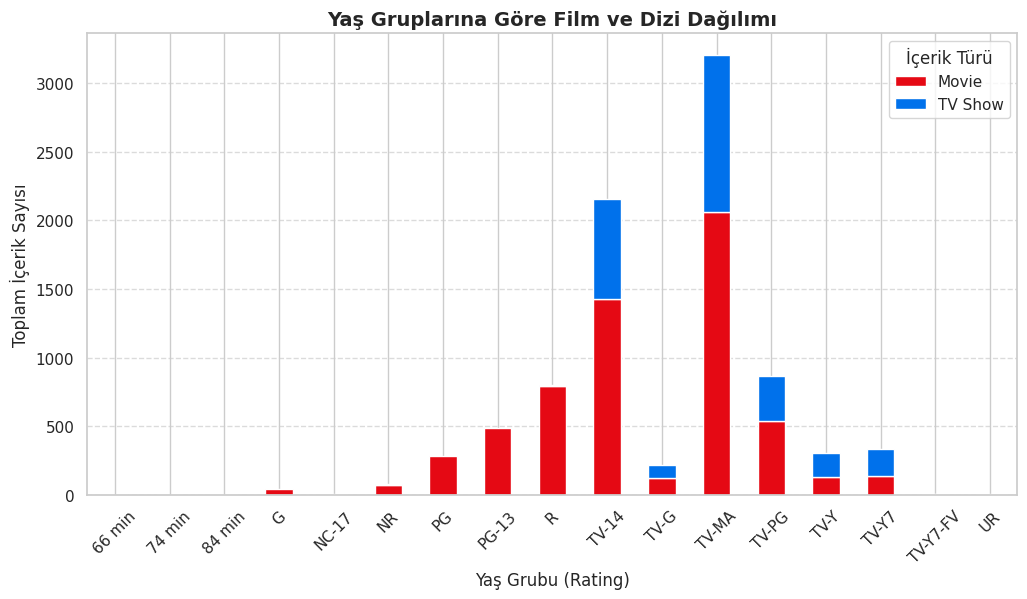

In [222]:


# --- GROUPBY ÖZET ANALİZİ ---

# Yaş grubuna (rating) ve Türüne (type) göre verileri gruplayıp sayalım
print("\n--- Yaş Grubu ve Türüne Göre İçerik Sayıları (Groupby) ---")
ozet_tablo = df.groupby(['rating', 'type']).size().unstack().fillna(0)
print(ozet_tablo)

# Bu Groupby sonucunu görselleştirelim
import matplotlib.pyplot as plt

ozet_tablo.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#E50914', '#0071EB'])

plt.title('Yaş Gruplarına Göre Film ve Dizi Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Yaş Grubu (Rating)')
plt.ylabel('Toplam İçerik Sayısı')
plt.legend(title='İçerik Türü')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Groupby fonksiyonu ile veriler "Yaş Grubu" ve "İçerik Türü"ne göre gruplanmış; hangi yaş grubunda kaç film ve kaç dizi olduğu özetlenmiştir.

TV-MA (Yetişkin) kategorisinin hem filmlerde hem de dizilerde en büyük paya sahip olduğu görülmektedir. Bu, platformun yetişkin kitlesine çok daha fazla içerik sunduğunu kanıtlar.

Çocuklara yönelik içeriklerin (TV-Y, TV-G) sayıca yetişkin içeriklerinin çok gerisinde kalması, Netflix'in genel izleyici stratejisinde yetişkin odaklı yapımların baskın olduğunu göstermektedir.

## 🏁 Sonuç

1-Netflix’te film sayısının dizi sayısından daha fazla olduğu görülmüştür. Netflix kütüphanesinin yaklaşık %70'ini filmler, %30'unu ise diziler oluşturmaktadır. Bu durum platformun hala film odaklı bir kütüphane stratejisi izlediğini göstermektedir.


2-İçerik sayısının yıllar içinde özellikle son yıllarda belirgin şekilde arttığı gözlemlenmiştir. 2015 yılından itibaren platforma eklenen içerik sayısında devasa bir ivme yakalanmış, özellikle yılın son aylarında (Ekim-Aralık) içerik girişlerinin zirve yaptığı görülmüştür.


3-Dram, Komedi ve Belgesel türleri platformun en baskın kategorileridir. Üretim kapasitesi bakımından Amerika Birleşik Devletleri liderliğini korurken, Hindistan film üretimiyle ikinci sırada yer almaktadır.


4-Rating dağılımına bakıldığında, belirli yaş gruplarına yönelik içeriklerin daha yoğun olduğu görülmektedir.

5-Yapılan ısı haritası (heatmap) analizi sonucunda, içeriklerin yapım yılı ile süreleri arasında anlamlı bir doğrusal ilişki bulunamamıştır; bu da Netflix'in her dönemden farklı uzunluklarda içeriklere eşit şans verdiğini kanıtlamaktadır

Genel olarak Netflix in zamanla büyüyen bir platform olduğu ve ağırlıklı olarak film içeriklerine yer verdiği söylenebilir. Ayrıca içerik çeşitliliğinin arttığı ve farklı kitlelere hitap eden yapımların bulunduğu dikkat çekmektedir.


